# Gaussian Process Generator

Gaussian Processes produce smooth, correlated time series whose roughness and periodicity are controlled by kernel functions (RBF, Matern, Periodic).

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import GaussianProcessGenerator

## 1. RBF Kernel (Smooth)

The RBF (Radial Basis Function) kernel produces infinitely differentiable, very smooth functions.

In [ ]:
rbf_gen = GaussianProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    kernel="rbf",
    length_scale=20.0,
    amplitude=1.0,
    seed=42,
)
rbf_df = rbf_gen.generate(n_series=1)

print(f"Generated {len(rbf_df)} observations with RBF kernel")
print(f"Statistics: Mean={rbf_df['y'].mean():.4f}, Std={rbf_df['y'].std():.4f}")
rbf_df.head(10)

Generated 200 observations with RBF kernel
Statistics: Mean=-0.3653, Std=0.6652


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,0.364978
"""0""",2000-01-02 00:00:00,0.327014
"""0""",2000-01-03 00:00:00,0.287466
"""0""",2000-01-04 00:00:00,0.242797
"""0""",2000-01-05 00:00:00,0.200276
"""0""",2000-01-06 00:00:00,0.156155
"""0""",2000-01-07 00:00:00,0.113067
"""0""",2000-01-08 00:00:00,0.071082
"""0""",2000-01-09 00:00:00,0.033798


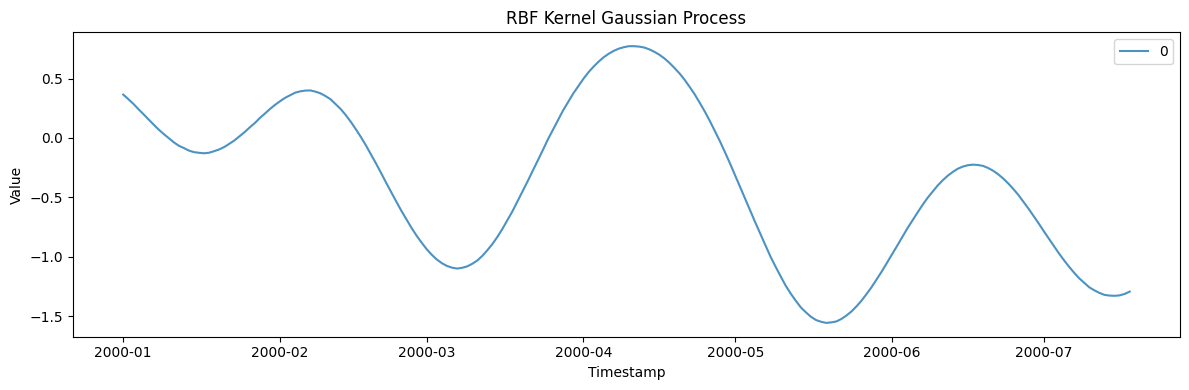

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in rbf_df["unique_id"].unique().to_list():
    series = rbf_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("RBF Kernel Gaussian Process")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Matern Kernels (Varying Roughness)

Matern kernels control roughness: 0.5 (rough, OU-like), 1.5 (once-differentiable), 2.5 (twice-differentiable).

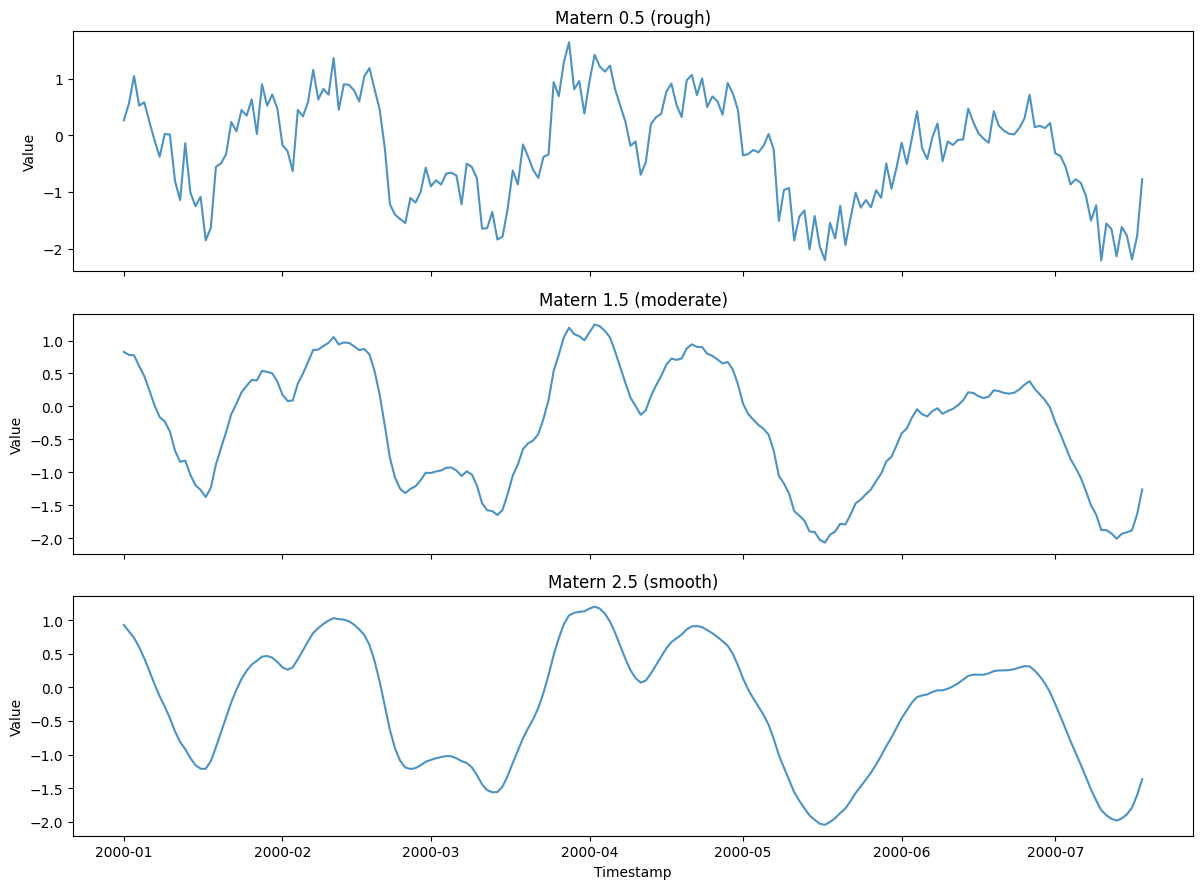

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, kernel, label in zip(
    axes,
    ["matern_0.5", "matern_1.5", "matern_2.5"],
    ["Matern 0.5 (rough)", "Matern 1.5 (moderate)", "Matern 2.5 (smooth)"],
):
    gen = GaussianProcessGenerator(engine="polars", 
        min_length=200, max_length=200, freq="D",
        kernel=kernel, length_scale=10.0, seed=42,
    )
    df = gen.generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.8)
    ax.set_ylabel("Value")
    ax.set_title(label)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 3. Periodic Kernel

The periodic kernel captures repeating patterns with a configurable period.

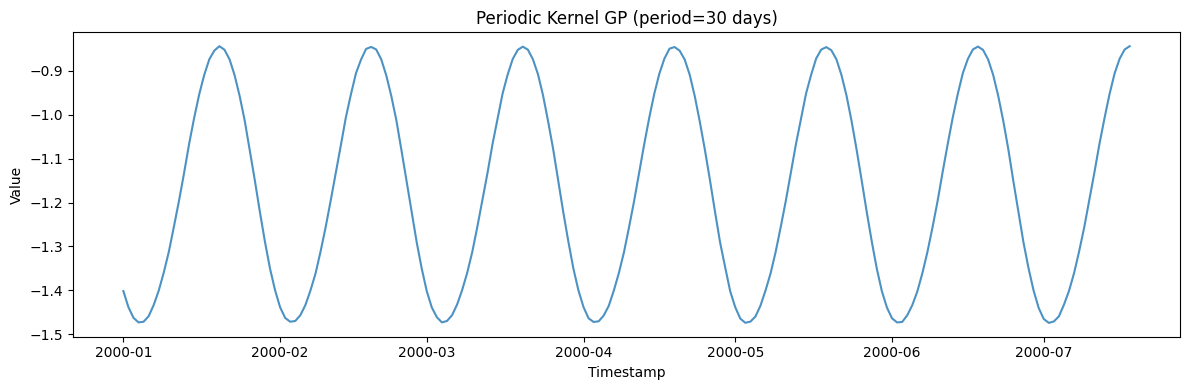

In [ ]:
periodic_gen = GaussianProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    kernel="periodic",
    length_scale=5.0,
    period=30.0,
    seed=42,
)
periodic_df = periodic_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periodic_df["ds"].to_list(), periodic_df["y"].to_list(), alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Periodic Kernel GP (period=30 days)")
plt.tight_layout()
plt.show()

## 4. Multiple Series

Generate multiple independent GP realizations.

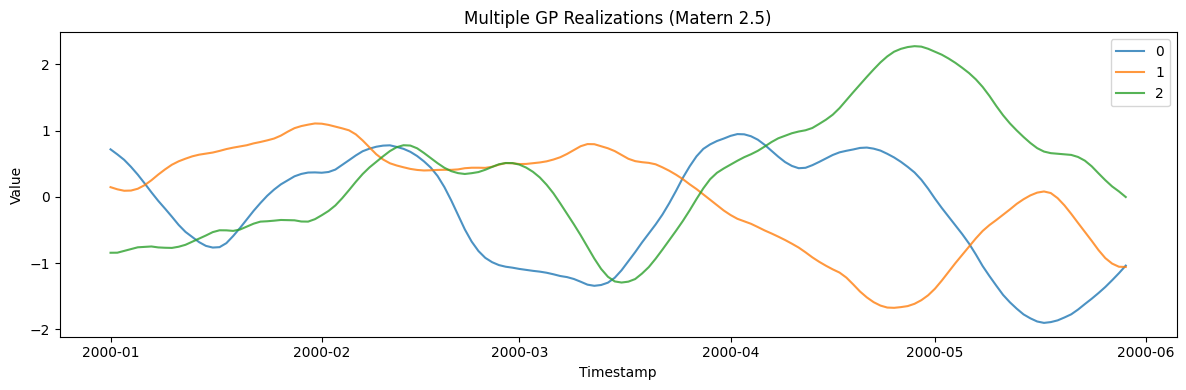

In [ ]:
multi_gen = GaussianProcessGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    kernel="matern_2.5", length_scale=15.0, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple GP Realizations (Matern 2.5)")
ax.legend()
plt.tight_layout()
plt.show()